# AI translation validation for Ubuntu - Model
Romain Darous
Exploration the LLM BERT

In [9]:
from transformers import BertTokenizer
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Loading the model
- Tokenizer
- Multinlingual BERT embedding

In [10]:
# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def inspect_tokens(text):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt')
    
    # Get the token IDs
    token_ids = inputs['input_ids'].squeeze().tolist()
    
    # Convert token IDs to tokens
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    
    # Print the tokens and their corresponding IDs
    for token_id, token in zip(token_ids, tokens):
        print(f"Token ID: {token_id}, Token: {token}")
    return tokens

# Example usage
text = "Hello, how are you?"
inspect_tokens(text)


Token ID: 101, Token: [CLS]
Token ID: 31178, Token: Hello
Token ID: 117, Token: ,
Token ID: 14796, Token: how
Token ID: 10301, Token: are
Token ID: 13028, Token: you
Token ID: 136, Token: ?
Token ID: 102, Token: [SEP]


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


['[CLS]', 'Hello', ',', 'how', 'are', 'you', '?', '[SEP]']

In [11]:
# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertModel.from_pretrained('bert-base-multilingual-cased')


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

In [12]:
def get_word_embeddings(text):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt')

    # Forward pass through the model
    with torch.no_grad():
        outputs = model(**inputs)

    # The embeddings are in the last_hidden_state
    embeddings = outputs.last_hidden_state

    # Convert embeddings to a list of numpy arrays
    embeddings_np = embeddings.squeeze().numpy()

    return embeddings_np

## Example on the Ukrainin hateful content of Ubuntu

In [13]:
# Reference string
text_1 = "This is the homepage security title"
embeddings_1 = get_word_embeddings(text_1)

print(embeddings_1.shape)  # Shape: (number of tokens, embedding dimension)

# Suggested translations
text_2 = "Посилене смоктання члену"
text_3 = "Das ist der Sicherheitstitel der Homepage"
embeddings_2 = get_word_embeddings(text_2)
embeddings_3 = get_word_embeddings(text_3)

print(embeddings_2.shape, embeddings_3)

(9, 768)
(10, 768) [[ 0.33518475 -0.19290888  0.17489219 ...  0.69031715  0.42865735
  -0.03032738]
 [ 0.42238894 -0.7204479   0.7449541  ...  0.557596    1.0353196
   0.19782388]
 [ 0.14993687 -0.34506625  0.24931465 ...  0.6889265   1.4844947
   0.38218933]
 ...
 [ 0.16411063 -0.71002203  0.55898106 ...  0.8043691   0.5660587
   0.5119506 ]
 [ 0.1373953  -0.45842665  1.085635   ...  0.36519855  0.7993699
   0.21387953]
 [ 0.34623677 -0.30684295  0.7854235  ...  0.6080958   0.84442806
   0.3473786 ]]


Token ID: 101, Token: [CLS]
Token ID: 11480, Token: По
Token ID: 64631, Token: ##сил
Token ID: 20516, Token: ##ене
Token ID: 16541, Token: см
Token ID: 11899, Token: ##ок
Token ID: 39979, Token: ##тання
Token ID: 16960, Token: член
Token ID: 10227, Token: ##у
Token ID: 102, Token: [SEP]
Token ID: 101, Token: [CLS]
Token ID: 10747, Token: This
Token ID: 10124, Token: is
Token ID: 10105, Token: the
Token ID: 11816, Token: home
Token ID: 36795, Token: ##page
Token ID: 21849, Token: security
Token ID: 12887, Token: title
Token ID: 102, Token: [SEP]


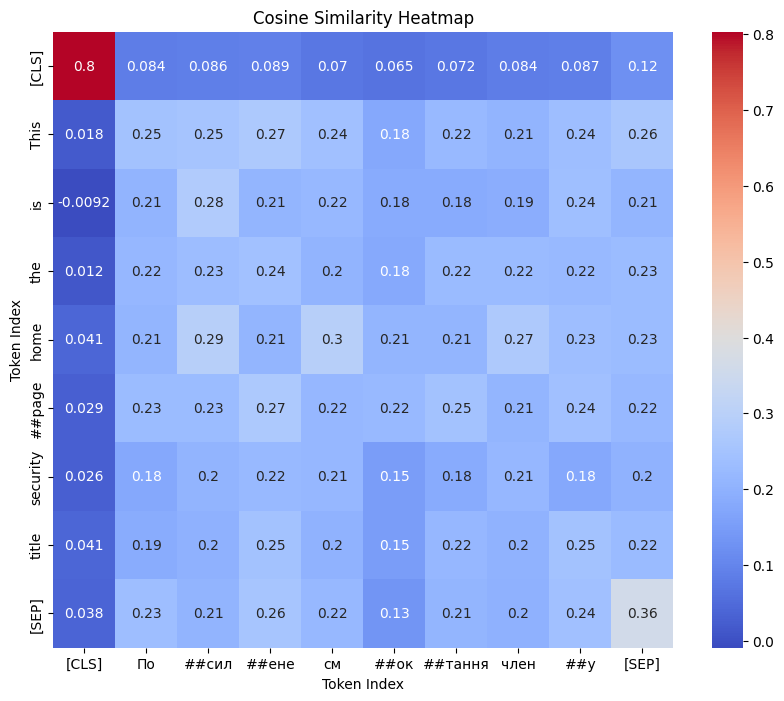

In [14]:
# Compute cosine similarity between embeddings_1 and embeddings_2
cos_sim_1_2 = cosine_similarity(embeddings_1, embeddings_2)

# Plot the heatmap with text_1 and text_2
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim_1_2, annot=True, cmap='coolwarm', xticklabels=inspect_tokens(text_2), yticklabels=inspect_tokens(text_1))
plt.xlabel('Token Index')
plt.ylabel('Token Index')
plt.title('Cosine Similarity Heatmap')
plt.show()

Token ID: 101, Token: [CLS]
Token ID: 18231, Token: Dies
Token ID: 10298, Token: ist
Token ID: 10118, Token: der
Token ID: 63961, Token: Sicherheit
Token ID: 11964, Token: ##sti
Token ID: 15636, Token: ##tel
Token ID: 10118, Token: der
Token ID: 86905, Token: Homepage
Token ID: 102, Token: [SEP]
Token ID: 101, Token: [CLS]
Token ID: 10747, Token: This
Token ID: 10124, Token: is
Token ID: 10105, Token: the
Token ID: 11816, Token: home
Token ID: 36795, Token: ##page
Token ID: 21849, Token: security
Token ID: 12887, Token: title
Token ID: 102, Token: [SEP]


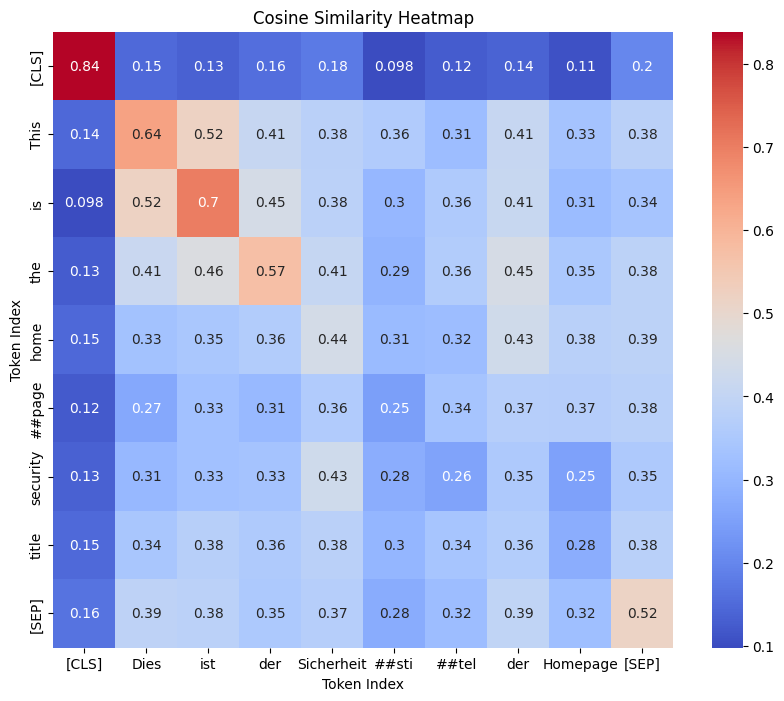

In [17]:
# Compute cosine similarity between embeddings_1 and embeddings_2
cos_sim_1_3 = cosine_similarity(embeddings_1, embeddings_3)

# Plot the heatmap with text_1 and text_3
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim_1_3, annot=True, cmap='coolwarm', xticklabels=inspect_tokens(text_3), yticklabels=inspect_tokens(text_1))
plt.xlabel('Token Index')
plt.ylabel('Token Index')
plt.title('Cosine Similarity Heatmap')
plt.show()

## Naive sentence embedding
By averaging the embedding of all the words of a sentence, we get a sentence of embedding. Computing the cosine similarity gives us a very simple way to compare them.

In [19]:
sent_1 = np.mean(embeddings_1, axis = 0)
sent_2 = np.mean(embeddings_2, axis=0)
sent_3 = np.mean(embeddings_3, axis=0)

# Computing cosine similarity between sentences
cos_sim_sentences_1_2 = cosine_similarity(sent_1.reshape(1, -1), sent_2.reshape(1, -1))
cos_sim_sentences_1_3 = cosine_similarity(sent_1.reshape(1, -1), sent_3.reshape(1, -1))
print(f"Cosine Similarity for hateful speech: {cos_sim_sentences_1_2[0][0]}")
print(f"Cosine Similarity for correct translation: {cos_sim_sentences_1_3[0][0]}")

Cosine Similarity for hateful speech: 0.3504699170589447
Cosine Similarity for correct translation: 0.5802498459815979


### Improving embedding
Idea : starting from a naive embedding, build a model that classifies whether or not the translations are close to each other.